# **Neural Network**

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**


In [ ]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)


target = 'cnt'
features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season','yr'
]

X = df[features].copy()
y = df[target].astype(float)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [ ]:
# A super-fast baseline, just for context
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': 19379.312944744703, 'LR_MAE': 104.79577059911452, 'LR_R2': 0.3879974354720257}


# **Task 2: Practical NN training techniques**
The task will illustrate some useful NN training techniques, including saving and loading the trained model, using the callback function to save the best model, and adding dropout layers.



Epoch 1: val_mae improved from None to 32.96970, saving model to weights.best.keras

Epoch 1: finished saving model to weights.best.keras

Epoch 2: val_mae improved from 32.96970 to 31.94460, saving model to weights.best.keras

Epoch 2: finished saving model to weights.best.keras

Epoch 3: val_mae did not improve from 31.94460

Epoch 4: val_mae did not improve from 31.94460

Epoch 5: val_mae did not improve from 31.94460

Epoch 6: val_mae improved from 31.94460 to 31.80076, saving model to weights.best.keras

Epoch 6: finished saving model to weights.best.keras

Epoch 7: val_mae did not improve from 31.80076

Epoch 8: val_mae improved from 31.80076 to 31.79096, saving model to weights.best.keras

Epoch 8: finished saving model to weights.best.keras

Epoch 9: val_mae did not improve from 31.79096

Epoch 10: val_mae improved from 31.79096 to 31.69456, saving model to weights.best.keras

Epoch 10: finished saving model to weights.best.keras

Epoch 11: val_mae improved from 31.69456 to 31

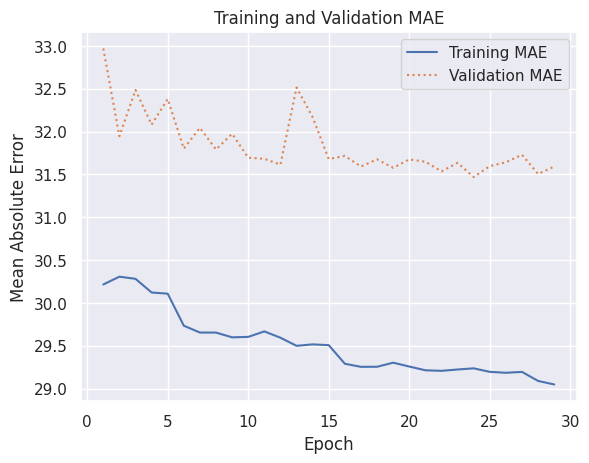

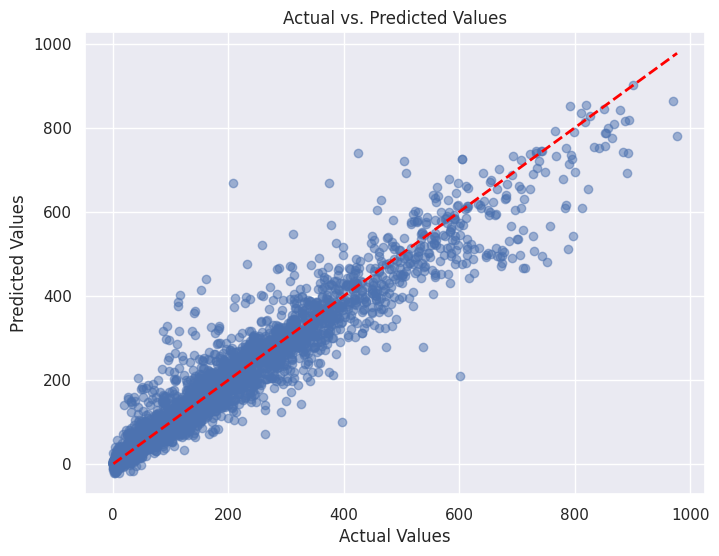

In [ ]:
from json import load
import pandas as pd
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model

#-------------------------------------------------data preprocessing------------------------------------------------------------------


#-------------------------------------------------network construction-----------------------------------------------------------------

#************************************************Here you can choose to add the dropout layer or not***************************
#
# def construct_network_model():
#   # Create a Sequential model, which is a linear stack of layers.
#   model = Sequential()
#
#   # Add a Dense layer with 32 units, ReLU activation, and an input dimension of 4.
#   model.add(Dense(32, activation='relu', input_dim=4))
#
#   # # Add a Dropout layer with a dropout rate of 0.5.
#   # model.add(Dropout(0.5))
#
#   # Add another Dense layer with 64 units and ReLU activation.
#   model.add(Dense(64, activation='relu'))
#
#   # # Add another Dropout layer with a dropout rate of 0.5.
#   # model.add(Dropout(0.5))
#
#   # Add a final Dense layer with 1 unit (typically used for regression tasks).
#   model.add(Dense(1))
#   return model
#
# model=construct_network_model()
# # Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# # and MAE metric to be used during training.
# model.compile(optimizer='adam', loss='mae', metrics=['mae'])
#************************************************Here you can choose to add the dropout layer or not*****************

#-------------------------------------------------model train------------------------------------------------------------------
# use the callback function to early stop, learning rate ajusting, save the best model
# Create an EarlyStopping callback to monitor the validation mean absolute error (val_mae).
# It will stop training if val_mae doesn't improve for 5 consecutive epochs and restores the best weights.
early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)

# Create a ReduceLROnPlateau callback to monitor val_mae.
# It reduces the learning rate by a factor of 0.5 if val_mae doesn't improve for 3 consecutive epochs.
reduce_lr = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=3)

# Define the file path where the best model will be saved.
filepath = "weights.best.keras"

# Create a ModelCheckpoint callback to monitor the validation mae (val_mae).
# The callback will save thhe model's weights only if the validation mae improves.
checkpoint = ModelCheckpoint(filepath, monitor='val_mae', verbose=1, save_best_only=True, mode='min')

# Train the model using the fit method.
hist_2 = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop, reduce_lr,checkpoint],verbose=0)


#-------------------------------------------------model evaluation--------------------------------------------------------------------

# Set the style of the plots using Seaborn.
sns.set()

# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']

# Define the number of epochs.
epochs = range(1, len(err) + 1)

# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--------------------------------------'+'this is result of the trained model'+"---------------------------------------------")
# Print the calculated metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

#-------------------------------------------------load model and evaluation--------------------------------------------------------------------
if not filepath =="":
  # Load a pre-trained model from the specified file path.
  model = load_model(filepath)

  # Use the loaded model to predict on the test data.
  y_pred = model.predict(X_test_scaled)

  # Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) for the predictions.
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print('--------------------------------------'+'this is result of the model loaded from the local path'+"---------------------------------------------")

  # Print the calculated metrics.
  print(f"Mean Absolute Error: {mae}")
  print(f"Mean Squared Error: {mse}")
  print(f"R-squared: {r2}")



  # Create a scatter plot to visualize the relationship
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

  # Add labels and title
  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title("Actual vs. Predicted Values")

  # Add a diagonal line for reference (perfect predictions)
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

  # Show the plot
  plt.show()


# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

## Tune hyperparameters

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
def create_model(hidden_layers, learning_rate):

    model = keras.Sequential()

    model.add(
        keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for units in hidden_layers:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu"
            )
        )

    model.add(keras.layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mae",
        metrics=["mae"]
    )

    return model

In [ ]:
def train_model(hidden_layers, learning_rate, batch_size, early_stopping_patience, reduce_lr_patience, reduce_lr_factor):

    tf.keras.backend.clear_session()

    model = create_model(
        hidden_layers=hidden_layers,
        learning_rate=learning_rate
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=early_stopping_patience,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=reduce_lr_factor,
        patience=reduce_lr_patience,
        min_lr=1e-6
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.10,
        epochs=100,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            reduce_lr
        ],
        verbose=0
    )

    best_val_mae = min(history.history["val_mae"])

    return model, history, best_val_mae

In [ ]:
training_configs = [
    # Baseline
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # Larger batch
    {"batch_size": 64, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # Smaller batch
    {"batch_size": 16, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # More patience
    {"batch_size": 32, "early_stopping_patience": 20, "reduce_lr_patience": 8, "reduce_lr_factor": 0.5},

    # Less patience
    {"batch_size": 32, "early_stopping_patience": 5, "reduce_lr_patience": 3, "reduce_lr_factor": 0.5},

    # Aggressive LR reduction
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.1},

    # Moderate LR reduction
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.2},

    # Slow LR reduction
    {"batch_size": 32, "early_stopping_patience": 20, "reduce_lr_patience": 10, "reduce_lr_factor": 0.5}
]

In [ ]:
results = []

for i, config in enumerate(training_configs):

    print(f"Model {i+1}/{len(training_configs)}")
    print(config)

    model, history, val_mae = train_model(
        hidden_layers=(32, 64),
        learning_rate=0.001,
        **config
    )

    results.append({
        **config,
        "val_mae": val_mae
    })

Model 1/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 2/8
{'batch_size': 64, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 3/8
{'batch_size': 16, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 4/8
{'batch_size': 32, 'early_stopping_patience': 20, 'reduce_lr_patience': 8, 'reduce_lr_factor': 0.5}
Model 5/8
{'batch_size': 32, 'early_stopping_patience': 5, 'reduce_lr_patience': 3, 'reduce_lr_factor': 0.5}
Model 6/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.1}
Model 7/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.2}
Model 8/8
{'batch_size': 32, 'early_stopping_patience': 20, 'reduce_lr_patience': 10, 'reduce_lr_factor': 0.5}


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "val_mae"
).reset_index(drop=True)

best_training = results_df.iloc[0]

print("Best training configuration:")
print(best_training)

Best training configuration:
batch_size                 16.00000
early_stopping_patience    10.00000
reduce_lr_patience          5.00000
reduce_lr_factor            0.50000
val_mae                    33.23357
Name: 0, dtype: float64


In [ ]:
architectures = [(32, 64), (64, 128), (32, 64, 32), (64, 128, 64)]

learning_rates = [0.001, 0.002]

In [ ]:
architecture_results = []

for architecture in architectures:

    for lr in learning_rates:

        print(
            f"Architecture: {architecture}, "
            f"Learning rate: {lr}"
        )

        model, history, val_mae = train_model(
            hidden_layers=architecture,
            learning_rate=lr,
            batch_size=int(best_training["batch_size"]),
            early_stopping_patience=int(
                best_training["early_stopping_patience"]
            ),
            reduce_lr_patience=int(
                best_training["reduce_lr_patience"]
            ),
            reduce_lr_factor=float(
                best_training["reduce_lr_factor"]
            )
        )

        architecture_results.append({
            "architecture": architecture,
            "learning_rate": lr,
            "val_mae": val_mae
        })

Architecture: (32, 64), Learning rate: 0.001
Architecture: (32, 64), Learning rate: 0.002
Architecture: (64, 128), Learning rate: 0.001
Architecture: (64, 128), Learning rate: 0.002
Architecture: (32, 64, 32), Learning rate: 0.001
Architecture: (32, 64, 32), Learning rate: 0.002
Architecture: (64, 128, 64), Learning rate: 0.001
Architecture: (64, 128, 64), Learning rate: 0.002


In [ ]:
architecture_results_df = pd.DataFrame(
    architecture_results
)

architecture_results_df = (
    architecture_results_df
    .sort_values("val_mae")
    .reset_index(drop=True)
)

best_architecture = architecture_results_df.iloc[0]

print("Best architecture:")
print(best_architecture)

Best architecture:
architecture     (64, 128, 64)
learning_rate            0.001
val_mae              25.764132
Name: 0, dtype: object


## Create a new model
Creating a Sequential model according to the best training configuration and architecture found:

Best training configuration:

* batch_size: 16
* early_stopping_patience: 10
* reduce_lr_patience: 5
* reduce_lr_factor: 0.5


Best architecture:

* architecture: (64, 128, 64)
* learning_rate: 0.002


In [ ]:
arch = best_architecture["architecture"]
lr = best_architecture["learning_rate"]

final_model = Sequential()

final_model.add(Dense(arch[0], activation = 'relu', input_dim = 11))

final_model.add(Dense(arch[1], activation = 'relu', input_dim = 11))

final_model.add(Dense(arch[2], activation = 'relu', input_dim = 11))

final_model.compile(optimizer = keras.optimizers.Adam(learning_rate=lr), loss = 'mae', metrics = ['mae'])

final_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,344 (67.75 KB)

 Trainable params: 17,344 (67.75 KB)

 Non-trainable params: 0 (0.00 B)

[]

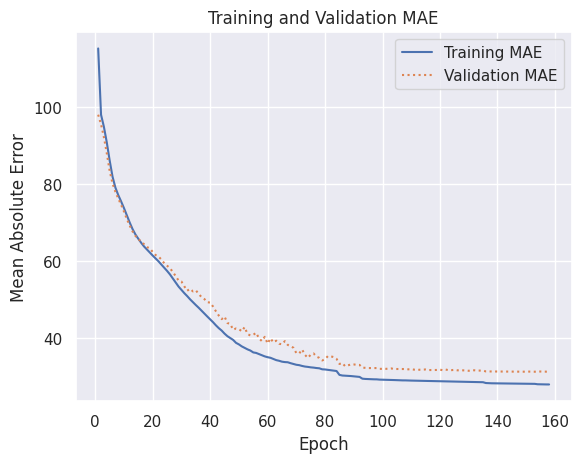

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

bs = best_training["batch_size"]
esp = best_training["early_stopping_patience"]
rlp = best_training["reduce_lr_patience"]
rlf = best_training["reduce_lr_factor"]

early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=esp, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=rlf, patience=rlp, min_lr=1e-6)

hist = final_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=500, batch_size=int(bs), callbacks=[early_stopping, reduce_lr], verbose=0)

sns.set()

err = hist.history['mae']
val_err = hist.history['val_mae']

epochs = range(1, len(err) + 1)

plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Neural Network VS Baseline Model (Linear Regression)")
print("----------------------------------------------------------")
print(f"MAE:  {mae:.4f}\t\t|  MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse:.4f}\t\t|  RMSE: {rmse_lr:.4f}")
print(f"R2:   {r2:.4f}\t\t|  R2: {r2_lr:.4f}")


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Final Neural Network VS Baseline Model (Linear Regression)
----------------------------------------------------------
MAE:  27.1320     |  MAE: 104.7958
RMSE: 44.4839    |  RMSE: 19379.3129
R2:   0.9375      |  R2: 0.3880


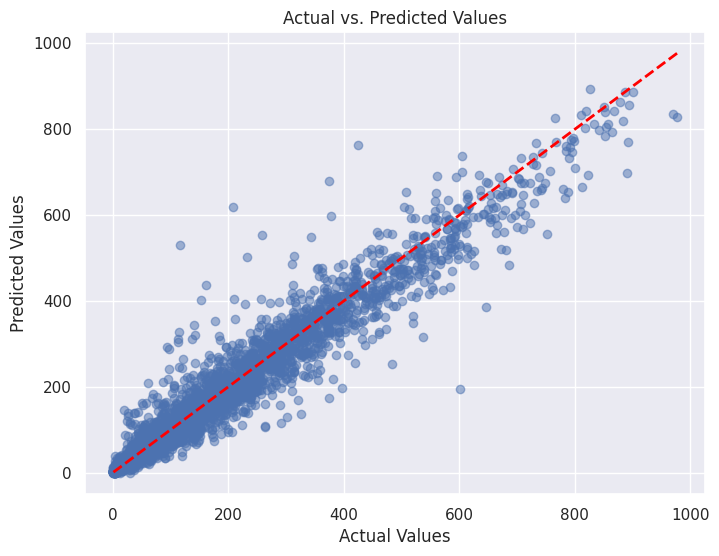

In [ ]:
 # Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()